## Cloth quality


In [11]:


import pandas as pd
import numpy as np
from scipy import stats

# 1️⃣ Load Data
df = pd.read_csv("cloth_quality_noisy_large.csv")
print("✅ Original data loaded successfully!")
print("Shape before cleaning:", df.shape)

# -------------------------
# 2️⃣ Handle Missing Values
# -------------------------
numeric_cols = df.select_dtypes(include=[float, int]).columns
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# -------------------------
# 3️⃣ Remove Invalid or Impossible Values
# -------------------------
df = df[df["Shrinkage"] >= 0]
df = df[df["GSM"] > 0]
df = df[df["TensileStrength"] > 0]

# -------------------------
# 4️⃣ Fix Label Noise
# -------------------------
df = df[df["Quality"].isin(["Low", "Medium", "High"])]

# -------------------------
# 5️⃣ Detect and Remove Outliers (Z-score)
# -------------------------
z = np.abs(stats.zscore(df[numeric_cols]))
df = df[(z < 3).all(axis=1)]

# -------------------------
# 6️⃣ Save Cleaned Data with Actual Values
# -------------------------
df.to_csv("cloth_quality_clean_actual.csv", index=False)
print("\n💾 Cleaned dataset (actual values) saved as 'cloth_quality_clean_actual.csv'")
print("Shape after cleaning:", df.shape)
print(df.head())


✅ Original data loaded successfully!
Shape before cleaning: (3000, 7)

💾 Cleaned dataset (actual values) saved as 'cloth_quality_clean_actual.csv'
Shape after cleaning: (2844, 7)
     GSM  ThreadDensity  TensileStrength  Shrinkage  AirPermeability  \
0  182.0          165.0            557.0       2.69            233.0   
1  186.0          142.0            579.0       6.54            687.0   
2  151.0          140.0            857.0       5.34            695.0   
3  268.0          131.0            649.0       9.44            442.0   
4  100.0          117.0            785.0       3.96            769.0   

   Thickness Quality  
0       0.41  Medium  
1       0.13  Medium  
2       0.59  Medium  
3       0.45  Medium  
4       0.19     Low  


C:\Users\Aroz\AppData\Local\Temp\ipykernel_3220\1190180399.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Aroz\AppData\Local\Temp\ipykernel_3220\1190180399.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

✅ Cleaned data loaded successfully from: cloth_quality_clean_actual.csv


C:\Users\Aroz\AppData\Local\Temp\ipykernel_3220\3818345365.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


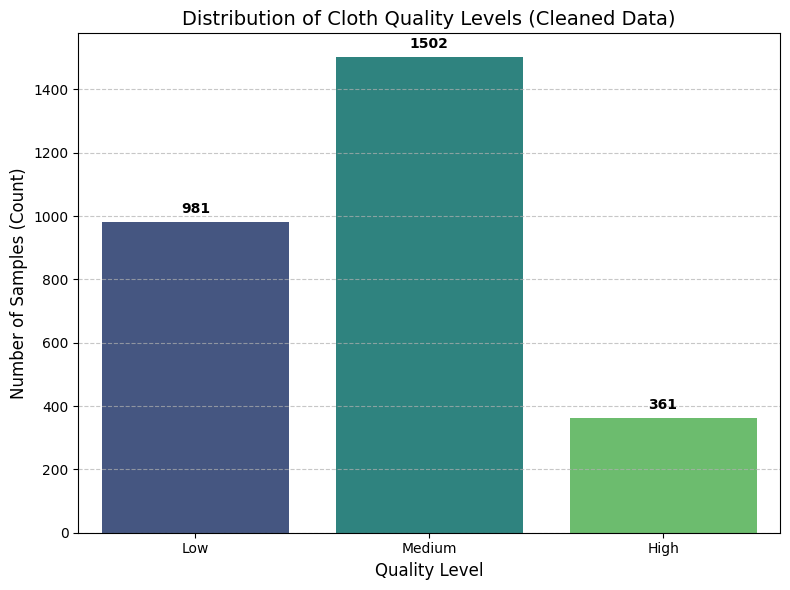

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Load the cleaned dataset
cleaned_file_name = "cloth_quality_clean_actual.csv"
try:
    df_clean = pd.read_csv(cleaned_file_name)
    print(f"✅ Cleaned data loaded successfully from: {cleaned_file_name}")
except FileNotFoundError:
    print(f"Error: The file {cleaned_file_name} was not found. Please ensure the cleaning cell was run first.")
    exit()

# 2️⃣ Count the occurrences of each Quality category
quality_counts = df_clean['Quality'].value_counts()

# Define the preferred order for the categories (Low, Medium, High)
order = ['Low', 'Medium', 'High']

# Reindex the series to ensure correct plotting order
quality_counts = quality_counts.reindex(order)

# 3️⃣ Create the bar plot visualization
plt.figure(figsize=(8, 6))

# Use seaborn for a nice aesthetic, plotting the counts
sns.barplot(
    x=quality_counts.index, 
    y=quality_counts.values, 
    palette="viridis"
)

# Add labels and title
plt.title('Distribution of Cloth Quality Levels (Cleaned Data)', fontsize=14)
plt.xlabel('Quality Level', fontsize=12)
plt.ylabel('Number of Samples (Count)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add the count value on top of each bar
for i, count in enumerate(quality_counts.values):
    plt.text(i, count + 20, str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')


plt.tight_layout()

# 4️⃣ Display the plot (it will show automatically in Jupyter)
plt.show()